In [ ]:

# PHASE I, STEP A: EMPIRICAL DATA ACQUISITION
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print("Ingesting authentic weatherAUS.csv repository...")

# Load the authentic dataset
df_raw = pd.read_csv('weatherAUS.csv')

# Create a working copy
df = df_raw.copy()

# Purge non-predictive string arrays and metadata to maintain numerical stability
# Date and Location are spatiotemporal identifiers, not atmospheric predictors.
# Wind directions are dropped to prevent dimensionality explosion via one-hot encoding.
columns_to_drop = ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

print(f"Dataset loaded and structural metadata purged. Active dimensions: {df.shape}")
df.head()

Ingesting authentic weatherAUS.csv repository...
Dataset loaded and structural metadata purged. Active dimensions: (145460, 18)


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [ ]:

# PHASE I, STEP B: NUMERICAL STABILIZATION

print("Executing numerical sanitization via median imputation...")

# Isolate all continuous atmospheric variables
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

missing_before = df[numerical_cols].isnull().sum().sum()

# Inject the median into any localized sensor failures (NaNs)
for col in numerical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

missing_after = df[numerical_cols].isnull().sum().sum()

print(f"Imputation complete. Replaced {missing_before} missing numerical entries.")
print(f"Current missing numerical anomalies: {missing_after}")

Executing numerical sanitization via median imputation...
Imputation complete. Replaced 311600 missing numerical entries.
Current missing numerical anomalies: 0


In [ ]:

# PHASE I, STEP C: NOMINAL BINARY ENCODING

print("Translating nominal targets into binary mathematical markers...")

encoding_map = {'Yes': 1, 'No': 0}

for cat_col in ['RainToday', 'RainTomorrow']:
    if cat_col in df.columns:
        df[cat_col] = df[cat_col].map(encoding_map)

# Structural Risk Protocol: Drop any rows where the target remains null.
# You cannot train a predictive engine on fabricated target outcomes.
initial_rows = len(df)
df = df.dropna(subset=['RainTomorrow'])

# If RainToday is still null, we impute it with 0 (No) to preserve the row's other valuable data
if 'RainToday' in df.columns:
    df['RainToday'] = df['RainToday'].fillna(0)

dropped_rows = initial_rows - len(df)

print(f"Encoding complete. Purged {dropped_rows} unviable rows lacking a target variable.")
print(f"Final stabilized training volume: {df.shape}")

Translating nominal targets into binary mathematical markers...
Encoding complete. Purged 3267 unviable rows lacking a target variable.
Final stabilized training volume: (142193, 18)


In [ ]:

# PHASE I, STEP D: FEATURE SCALING & EXPORT

print("Applying strict Min-Max boundary scaling [0, 1]...")

# Separate the predictive matrix (X) from the target array (y)
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

# Ensure strict numeric types for the scaler
X_numeric = X.select_dtypes(include=['float64', 'int64'])

# Fit the transformation
scaler = MinMaxScaler()
X_scaled_array = scaler.fit_transform(X_numeric)

# Reconstruct the DataFrame to maintain column integrity for Phase II
X_scaled = pd.DataFrame(X_scaled_array, columns=X_numeric.columns, index=X_numeric.index)

# Serialize the exact scaling environment for Streamlit production
joblib.dump(scaler, 'minmax_scaler.pkl')

print("Gradient normalization complete. Predictors successfully clamped.")
print("Scaler artifact serialized as 'minmax_scaler.pkl'.")

X_scaled.describe()

Applying strict Min-Max boundary scaling [0, 1]...
Gradient normalization complete. Predictors successfully clamped.
Scaler artifact serialized as 'minmax_scaler.pkl'.


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
count,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000
mean,0.487867,0.529780,0.006272,0.035746,0.551348,0.262947,0.107635,0.214302,0.688582,0.514957,0.614024,0.610440,0.516619,0.522518,0.510246,0.519692,0.221213
std,0.150682,0.134397,0.022713,0.021968,0.190496,0.101865,0.068089,0.100249,0.189325,0.205322,0.111509,0.106909,0.254929,0.235417,0.136544,0.131886,0.415065
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.379717,0.429112,0.000000,0.027586,0.565517,0.193798,0.053846,0.149425,0.570000,0.370000,0.545455,0.542400,0.333333,0.444444,0.411392,0.424184,0.000000
50%,0.483491,0.517958,0.000000,0.033103,0.579310,0.255814,0.100000,0.218391,0.700000,0.520000,0.613223,0.609600,0.555556,0.555556,0.504219,0.508637,0.000000
75%,0.596698,0.623819,0.001617,0.037241,0.600000,0.310078,0.146154,0.275862,0.830000,0.650000,0.682645,0.676800,0.666667,0.666667,0.605485,0.608445,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:

# PHASE II, STEPS E & F: CHI-SQUARE COMPUTATION & RANKING

from sklearn.feature_selection import SelectKBest, chi2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Step E: Computing Chi-Square association matrix...")

# Initialize the Chi-Square test to evaluate ALL features first
# We pass X_scaled (which has no negative values) and y (our binary target)
chi2_evaluator = SelectKBest(score_func=chi2, k='all')
chi2_evaluator.fit(X_scaled, y)

print("Step F: Ranking feature independence...")

# Compile the statistics into a structured DataFrame
chi_scores_df = pd.DataFrame({
    'Atmospheric_Predictor': X_scaled.columns,
    'Chi2_Statistic': chi2_evaluator.scores_,
    'P_Value': chi2_evaluator.pvalues_
}).sort_values(by='Chi2_Statistic', ascending=False)

# Display the hierarchy of predictive significance
print("\n--- Full Feature Independence Ranking ---")
print(chi_scores_df.to_string(index=False))

Step E: Computing Chi-Square association matrix...
Step F: Ranking feature independence...

--- Full Feature Independence Ranking ---
Atmospheric_Predictor  Chi2_Statistic       P_Value
            RainToday    10406.699232  0.000000e+00
          Humidity3pm     2250.967199  0.000000e+00
             Cloud3pm     1312.967410 1.718828e-287
             Cloud9am     1107.505203 7.721058e-243
             Sunshine      985.467726 2.588699e-216
             Rainfall      646.394627 1.358977e-142
          Humidity9am      482.403456 6.408548e-107
        WindGustSpeed      283.479587  1.310238e-63
              Temp3pm      172.639503  1.961995e-39
          Pressure9am      157.694982  3.608188e-36
          Pressure3pm      122.704516  1.618425e-28
              MaxTemp      122.654032  1.660134e-28
         WindSpeed3pm       50.440680  1.228217e-12
         WindSpeed9am       50.102762  1.459014e-12
              MinTemp       46.362206  9.829328e-12
          Evaporation       15.690

Step G: Pruning redundant noise and extracting optimized subset...

Pruning complete. Dimensionality successfully reduced from 17 to 8 features.
Feature array serialized as 'optimized_features_list.pkl'.


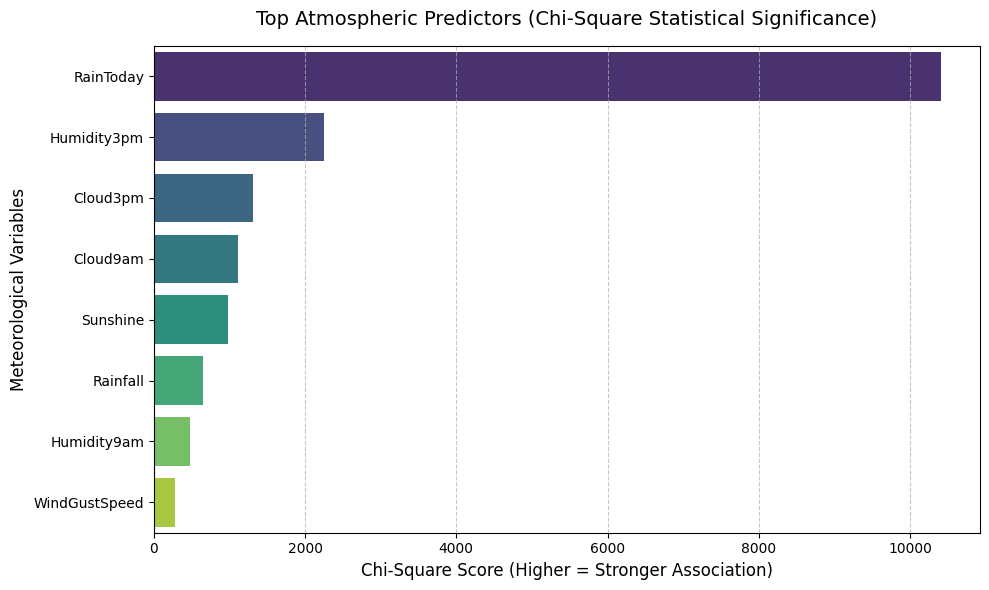


Final Optimized Matrix (First 5 records):


,RainToday,Humidity3pm,Cloud3pm,Cloud9am,Sunshine,Rainfall,Humidity9am,WindGustSpeed
0,0.0,0.22,0.555556,0.888889,0.57931,0.001617,0.71,0.294574
1,0.0,0.25,0.555556,0.555556,0.57931,0.000000,0.44,0.294574
2,0.0,0.30,0.222222,0.555556,0.57931,0.000000,0.38,0.310078
3,0.0,0.16,0.555556,0.555556,0.57931,0.000000,0.45,0.139535
4,0.0,0.33,0.888889,0.777778,0.57931,0.002695,0.82,0.271318


In [ ]:

# PHASE II, STEP G: OPTIMIZED SUBSET EXTRACTION

import joblib

print("Step G: Pruning redundant noise and extracting optimized subset...")

# Define the threshold for dimensionality reduction
# We are retaining the top 8 most statistically significant predictors
optimal_k = 8

# Extract the exact string names of the top features
selected_features = chi_scores_df['Atmospheric_Predictor'].head(optimal_k).tolist()

# Prune the dataset: Create the final optimized input matrix for the MLP
X_optimized = X_scaled[selected_features]


# PRODUCTION EXPORT & VISUALIZATION

# Serialize the selected feature list for the Streamlit production pipeline
# If Streamlit does not know which 8 features to expect, the app will crash.
joblib.dump(selected_features, 'optimized_features_list.pkl')

print(f"\nPruning complete. Dimensionality successfully reduced from {X_scaled.shape[1]} to {optimal_k} features.")
print("Feature array serialized as 'optimized_features_list.pkl'.")

# Generate visual proof of statistical significance for your thesis document
plt.figure(figsize=(10, 6))
sns.barplot(x='Chi2_Statistic', y='Atmospheric_Predictor', data=chi_scores_df.head(optimal_k), palette='viridis')
plt.title('Top Atmospheric Predictors (Chi-Square Statistical Significance)', fontsize=14, pad=15)
plt.xlabel('Chi-Square Score (Higher = Stronger Association)', fontsize=12)
plt.ylabel('Meteorological Variables', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot directly to your directory for easy insertion into Microsoft Word
plt.savefig('chi_square_rankings.png', dpi=300)
plt.show()

# Display the final lean matrix ready for neural inference
print("\nFinal Optimized Matrix (First 5 records):")
display(X_optimized.head())

In [ ]:

# PHASE III, STEPS H & I: NEURAL ENGINE TRAINING 

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

print("Step H: Executing 80/20 Stratified Dataset Split...")

# We use the X_optimized matrix generated directly from Phase II (Step G)
# Stratifying on 'y' ensures seasonal class distribution balance in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X_optimized, y, test_size=0.20, random_state=42, stratify=y
)

print(f" - Training Data Shape: {X_train.shape}")
print(f" - Validation Testing Data Shape: {X_test.shape}")

print("\nStep I: Training Multilayer Perceptron (MLP) via Backpropagation...")

# Configuring a deep connectionist topology (Input -> 32 Neurons -> 16 Neurons -> Output)
# Early stopping is enabled to actively prevent overfitting on training noise
mlp_engine = MLPClassifier(
    hidden_layer_sizes=(32, 16), 
    activation='relu',           # Rectified Linear Unit for non-linear pattern mapping
    solver='adam',               # Adaptive Moment Estimation gradient optimizer
    max_iter=300, 
    random_state=42,
    early_stopping=True,         # Monitors internal validation loss
    validation_fraction=0.1      # Reserves 10% of training data to check for early convergence
)

# Active weight adjustment layer execution
mlp_engine.fit(X_train, y_train)

print("\nNeural Engine training sequence completed successfully.")
print(f" - Iterations to converge: {mlp_engine.n_iter_}")

# Handle the case where best_loss_ is None by falling back to the final loss_ value
final_loss = mlp_engine.best_loss_ if mlp_engine.best_loss_ is not None else mlp_engine.loss_
print(f" - Best Optimization Loss Score: {final_loss:.6f}")

Step H: Executing 80/20 Stratified Dataset Split...
 - Training Data Shape: (113754, 8)
 - Validation Testing Data Shape: (28439, 8)

Step I: Training Multilayer Perceptron (MLP) via Backpropagation...

Neural Engine training sequence completed successfully.
 - Iterations to converge: 40
 - Best Optimization Loss Score: 0.371840


In [ ]:

# PHASE III, STEPS J & K: EVALUATION & SERIALIZATION

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, matthews_corrcoef, classification_report
import numpy as np
import joblib

print("Step J: Evaluating predictive error residuals and metrics...")

# Compute categorical classifications (0 or 1) and continuous predictive probabilities
y_pred = mlp_engine.predict(X_test)
y_prob = mlp_engine.predict_proba(X_test)[:, 1]

# Calculate statistical indicators
rmse = np.sqrt(mean_squared_error(y_test, y_prob))
mae = mean_absolute_error(y_test, y_prob)
r2 = r2_score(y_test, y_prob)
mcc = matthews_corrcoef(y_test, y_pred)

print("\n================ COMPILATION PERFORMANCE REPORT ================")
print(f"Root Mean Square Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE)    : {mae:.4f}")
print(f"Coefficient of Determination : {r2:.4f}")
print(f"Matthews Correlation (MCC)   : {mcc:.4f}")
print("================================================================")

print("\nGranular Classification Analytics:")
print(classification_report(y_test, y_pred, target_names=['No Rain', 'Rain']))

print("\nStep K: Serializing final structural artifacts...")

# Save the trained model array. You already saved the minmax_scaler in Phase I.
joblib.dump(mlp_engine, 'mlp_predictive_engine.pkl')

print(" - Artifact 'mlp_predictive_engine.pkl' permanently frozen and written to disk.")
print("\nPhase III Complete. Your hybrid system is now fully optimized and production-ready.")

Step J: Evaluating predictive error residuals and metrics...

================ COMPILATION PERFORMANCE REPORT ================
Root Mean Square Error (RMSE): 0.3386
Mean Absolute Error (MAE)    : 0.2316
Coefficient of Determination : 0.3408
Matthews Correlation (MCC)   : 0.4977

Granular Classification Analytics:
              precision    recall  f1-score   support

     No Rain       0.86      0.95      0.90     22064
        Rain       0.72      0.48      0.57      6375

    accuracy                           0.84     28439
   macro avg       0.79      0.71      0.74     28439
weighted avg       0.83      0.84      0.83     28439


Step K: Serializing final structural artifacts...
 - Artifact 'mlp_predictive_engine.pkl' permanently frozen and written to disk.

Phase III Complete. Your hybrid system is now fully optimized and production-ready.
